<a href="https://colab.research.google.com/github/VuTuanAnh0949/RAG-LangChain-Ablation-Study/blob/main/RAG_Ablation_Reranker_MMR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup


### 1.1 Install required packages

In [ ]:
!pip install -q \
  "langchain>=0.2.0" \
  "langchain-core>=0.2.0" \
  "langchain-community>=0.1.0" \
  "langchain-text-splitters>=0.2.0" \
  "chromadb>=0.5.0" \
  "langchain-chroma>=0.2.0" \
  "pypdf" \
  "ragas>=0.2.0" \
  "datasets>=2.14.0" \
  "pandas" \
  "matplotlib" \
  "seaborn" \
  "openai>=1.0.0" \
  "langchain-openai>=0.1.0" \
  "gdown" \
  "tiktoken" \
  "nest_asyncio"

### 1.2 Import libraries

In [ ]:
import os
import re
import json
import glob
import time
import gdown
import random
import asyncio
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import nest_asyncio
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from typing import List
from openai import OpenAI
from google.colab import userdata
from langchain_chroma import Chroma

from datasets import Dataset

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas.embeddings import LangchainEmbeddingsWrapper

nest_asyncio.apply()

### 1.3 Set global seed for reproducibility (SEED = 42)

In [ ]:
SEED = 42

def set_global_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"Global seed set to {seed_value}")

set_global_seed(SEED)

### 1.4 Configure API Keys

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
print("OpenAI API Key configured successfully")

### *1.5 Batch Processing Configuration (MMR)

In [ ]:
BATCH_SIZE = 32
EMBEDDING_BATCH_SIZE = 100

LLM_MODEL = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# MMR (Maximal Marginal Relevance) Configuration
MMR_K = 3              # Final number of documents to return
MMR_FETCH_K = 10       # Number of documents to fetch before MMR
MMR_LAMBDA_MULT = 0.5  # Balance between relevance (1.0) and diversity (0.0)

EVAL_SAMPLE_SIZE = None
EVAL_MAX_WORKERS = 64
EVAL_TIMEOUT = 180

print(f"Configuration:")
print(f"  - LLM Model: {LLM_MODEL}")
print(f"  - Embedding Model: {EMBEDDING_MODEL}")
print(f"  - Retrieval: MMR (Maximal Marginal Relevance)")
print(f"  - MMR K: {MMR_K}, Fetch K: {MMR_FETCH_K}, Lambda: {MMR_LAMBDA_MULT}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - RAGAS Eval Workers: {EVAL_MAX_WORKERS}")
print(f"  - Eval Sample Size: {'ALL' if EVAL_SAMPLE_SIZE is None else EVAL_SAMPLE_SIZE}")

## 2. Data Preparation


### 2.1 Download data

In [ ]:
!gdown 1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW

In [ ]:
file_id = "1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW"
zip_path = "/content/data.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

!unzip -o /content/data.zip
DATA_DIR = "RAG_DATA"

### 2.2 Download testing file

In [ ]:
file_id = "1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

## 3. Model Configuration (API-based)


In [ ]:
def get_llm(
    model_name: str = LLM_MODEL,
    temperature: float = 0.0,
    max_tokens: int = 8192,
    seed: int = SEED,
):
    llm = ChatOpenAI(
        model=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
        seed=seed,
        api_key=OPENAI_API_KEY,
    )
    print(f"LLM initialized: {model_name} (seed={seed})")
    return llm


def get_embeddings(
    model_name: str = EMBEDDING_MODEL,
    chunk_size: int = EMBEDDING_BATCH_SIZE,
):
    embeddings = OpenAIEmbeddings(
        model=model_name,
        api_key=OPENAI_API_KEY,
        chunk_size=chunk_size,
    )
    print(f"Embeddings initialized: {model_name} (batch_size={chunk_size})")
    return embeddings

## 4. RAG Components


### 4.1 Define Vietnamese text cleaning function

In [ ]:
def clean_vietnamese_text(text: str) -> str:
    text = unicodedata.normalize('NFC', text)
    text = "".join(
        char for char in text
        if not unicodedata.category(char).startswith('C') or char in '\n\t'
    )
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n', text)
    return text.strip()

### 4.2 Define document loader and text splitter

In [ ]:
class SimpleLoader:
    def load_pdf(self, pdf_file: str):
        docs = PyPDFLoader(pdf_file, extract_images=True).load()
        for doc in docs:
            doc.page_content = clean_vietnamese_text(doc.page_content)
        return docs

    def load_dir(self, dir_path: str) -> List:
        pdf_files = glob.glob(f"{dir_path}/*.pdf")
        if not pdf_files:
            raise ValueError(f"No PDF files found in {dir_path}")

        all_docs = []
        for pdf_file in tqdm(pdf_files, desc="Loading PDFs"):
            try:
                all_docs.extend(self.load_pdf(pdf_file))
            except Exception as e:
                pass
        return all_docs


class TextSplitter:
    def __init__(
        self,
        chunk_size: int = 1024,
        chunk_overlap: int = 128,
    ):
        self.splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", " ", ""],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
        )

    def split(self, documents):
        return self.splitter.split_documents(documents)

### *4.3 Define vector database class with MMR retrieval

In [ ]:
class VectorDB:
    def __init__(
        self,
        documents=None,
        embedding=None,
        collection_name: str = "vietnamese_docs",
        persist_dir: str = "/content/chroma_data",
    ):
        self.persist_dir = persist_dir
        self.collection_name = collection_name
        self.embedding = embedding or get_embeddings()
        self.db = self._build_db(documents)

    def _build_db(self, documents):
        if documents is None or len(documents) == 0:
            db = Chroma(
                collection_name=self.collection_name,
                embedding_function=self.embedding,
                persist_directory=self.persist_dir,
            )
        else:
            print(f"Building vector database with {len(documents)} documents...")
            db = Chroma.from_documents(
                documents=documents,
                embedding=self.embedding,
                collection_name=self.collection_name,
                persist_directory=self.persist_dir,
            )
            print(f"Vector database built successfully!")
        return db

    def get_retriever(self, search_kwargs: dict = None):
        # Use MMR (Maximal Marginal Relevance) for diversity
        if search_kwargs is None:
            search_kwargs = {
                "k": MMR_K,
                "fetch_k": MMR_FETCH_K,
                "lambda_mult": MMR_LAMBDA_MULT
            }

        return self.db.as_retriever(
            search_type="mmr",  # Changed from "similarity" to "mmr"
            search_kwargs=search_kwargs,
        )

### 4.4 Define RAG pipeline with batch processing

In [ ]:
class FocusedAnswerParser(StrOutputParser):
    def parse(self, text: str) -> str:
        text = (text or "").strip()
        if "[TRẢ LỜI]:" in text:
            answer = text.split("[TRẢ LỜI]:")[-1].strip()
        else:
            answer = text

        answer = re.sub(r'^\s*[•\-\*]\s*', '', answer, flags=re.MULTILINE)
        answer = re.sub(r'\n+', ' ', answer).strip()
        return answer


class BatchRAG:
    def __init__(self, llm, batch_size: int = BATCH_SIZE):
        self.llm = llm
        self.batch_size = batch_size
        self.prompt_template = """Bạn là trợ lý AI phân tích tài liệu tiếng Việt.

[TÀI LIỆU]:
{context}

[CÂU HỎI]:
{question}

Hãy trả lời dựa trên tài liệu. Nếu tài liệu không có thông tin, nói rõ "Không có thông tin".
[TRẢ LỜI]:"""
        self.prompt = PromptTemplate.from_template(self.prompt_template)
        self.answer_parser = FocusedAnswerParser()

    def _format_docs(self, docs):
        formatted = []
        seen = set()
        for doc in docs:
            content = (doc.page_content or "").strip()
            if content and len(content) > 40 and content not in seen:
                formatted.append(content)
                seen.add(content)
        return "\n\n".join(formatted)

    def get_chain(self, retriever):
        def format_docs(docs):
            return self._format_docs(docs)

        rag_chain = (
            {"context": retriever | format_docs, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | self.answer_parser
        )
        return rag_chain

    def batch_retrieve(self, questions: List[str], retriever) -> List[dict]:
        all_contexts = []
        for question in tqdm(questions, desc="Retrieving documents (MMR)"):
            docs = retriever.invoke(question)
            contexts = [(doc.page_content or "") for doc in docs]
            formatted_context = self._format_docs(docs)
            all_contexts.append({
                "question": question,
                "contexts": contexts,
                "formatted_context": formatted_context
            })
        return all_contexts

    def batch_generate(self, prompts: List[str]) -> List[str]:
        from langchain_core.messages import HumanMessage

        all_answers = []
        for i in tqdm(range(0, len(prompts), self.batch_size), desc="Generating answers"):
            batch = prompts[i:i + self.batch_size]

            messages_batch = [[HumanMessage(content=p)] for p in batch]
            batch_results = self.llm.batch(messages_batch)

            for result in batch_results:
                answer = self.answer_parser.parse(result.content)
                all_answers.append(answer)

        return all_answers

    def answer_with_contexts_batch(self, questions: List[str], retriever):
        print(f"Processing {len(questions)} questions in batches of {self.batch_size}...")
        print(f"Using MMR retrieval (lambda={MMR_LAMBDA_MULT}, fetch_k={MMR_FETCH_K})")
        retrieved_data = self.batch_retrieve(questions, retriever)
        prompts = [
            self.prompt.format(
                context=data["formatted_context"],
                question=data["question"]
            )
            for data in retrieved_data
        ]
        answers = self.batch_generate(prompts)

        results = []
        for data, answer in zip(retrieved_data, answers):
            results.append({
                "answer": answer,
                "contexts": data["contexts"]
            })

        return results

## *5. RAG System Initialization


In [ ]:
set_global_seed(SEED)

llm = get_llm(model_name=LLM_MODEL, seed=SEED)
embeddings = get_embeddings(model_name=EMBEDDING_MODEL, chunk_size=EMBEDDING_BATCH_SIZE)

loader = SimpleLoader()
text_splitter = TextSplitter(chunk_size=1024, chunk_overlap=128)

raw_docs = loader.load_dir(DATA_DIR)
split_docs = text_splitter.split(raw_docs)
print(f"Total documents: {len(raw_docs)}, Split chunks: {len(split_docs)}")

vdb = VectorDB(documents=split_docs, embedding=embeddings)

# Initialize retriever with MMR settings
retriever = vdb.get_retriever(search_kwargs={
    "k": MMR_K,
    "fetch_k": MMR_FETCH_K,
    "lambda_mult": MMR_LAMBDA_MULT
})

rag = BatchRAG(llm, batch_size=BATCH_SIZE)
rag_chain = rag.get_chain(retriever)

print("\n" + "="*50)
print("RAG System initialized successfully!")
print(f"  - LLM: {LLM_MODEL} (API)")
print(f"  - Embeddings: {EMBEDDING_MODEL} (API)")
print(f"  - Retrieval: MMR (Maximal Marginal Relevance)")
print(f"  - MMR K: {MMR_K}, Fetch K: {MMR_FETCH_K}, Lambda: {MMR_LAMBDA_MULT}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Seed: {SEED}")
print("="*50)

## 6. Evaluation


### 6.1 Load testing data from JSON

In [ ]:
testset_path = 'testset.json'

with open(testset_path, 'r', encoding='utf-8') as f:
    testset_data = json.load(f)

test_df = pd.DataFrame([
    {
        'user_input': item['user_input'],
        'reference': item['reference'],
        'reference_contexts': item['reference_contexts']
    }
    for item in testset_data
])

print(f"Loaded {len(test_df)} test questions from testset.json")
display(test_df.head())

### *6.2 Run batch predictions on test questions (MMR)

In [ ]:
set_global_seed(SEED)

print(f"LLM: {LLM_MODEL}")
print(f"Retrieval: MMR (lambda={MMR_LAMBDA_MULT})")
print(f"Batch size: {BATCH_SIZE}")

questions = test_df['user_input'].tolist()

start_time = time.time()
batch_results = rag.answer_with_contexts_batch(questions, retriever)
elapsed_time = time.time() - start_time

print(f"Inference completed in {elapsed_time:.2f} seconds")
print(f"Average time per question: {elapsed_time/len(questions):.2f} seconds")

results = []
for idx, (result, (_, row)) in enumerate(zip(batch_results, test_df.iterrows())):
    results.append({
        "user_input": row['user_input'],
        "response": result["answer"],
        "retrieved_contexts": result["contexts"],
        "reference": row.get('reference', ''),
        "reference_contexts": row.get('reference_contexts', [])
    })

eval_df = pd.DataFrame(results)
print(f"Collected {len(eval_df)} predictions")
display(eval_df.head())

### 6.3 Evaluate RAG with RAGAS metrics (⚡ Optimized for Speed)

In [ ]:
if EVAL_SAMPLE_SIZE is not None:
    eval_subset = eval_df.sample(n=min(EVAL_SAMPLE_SIZE, len(eval_df)), random_state=SEED)
    print(f"Quick evaluation mode: Using {len(eval_subset)} samples")
else:
    eval_subset = eval_df
    print(f"Full evaluation: Using all {len(eval_subset)} samples")

eval_dataset = Dataset.from_pandas(eval_subset.reset_index(drop=True))

wrapped_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model='text-embedding-3-small')
)

run_config = RunConfig(
    max_workers=EVAL_MAX_WORKERS,
    timeout=EVAL_TIMEOUT,
    max_retries=1,
    max_wait=60,
)

print(f"Running RAGAS evaluation...")
print(f"   - Parallel workers: {EVAL_MAX_WORKERS}")
print(f"   - Samples: {len(eval_subset)}")

start_time = time.time()

ragas_results = evaluate(
    dataset=eval_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    embeddings=wrapped_embeddings,
    run_config=run_config,
    raise_exceptions=False,
)

eval_time = time.time() - start_time
print(f"\nEvaluation completed in {eval_time:.1f} seconds")
print(f"  Average: {eval_time/len(eval_subset):.2f}s per sample")

print("=" * 50)
print("=== RAGAS SCORES (MMR Retrieval) ===")
print("=" * 50)
print(ragas_results)

Full evaluation: Using all 52 samples
Running RAGAS evaluation...
   - Parallel workers: 64
   - Samples: 52


/tmp/ipython-input-4208205745.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  wrapped_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/208 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[80]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    The output is incomplete due to a max_tokens length limit.
</exception>
<completion>
    ChatCompletion(id='chatcmpl-CsZ1YxOVHNWo7LQAMUpWK6aZWujzy', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n    "statements": [\n        {\n            "statement": "Để xác định đúng vấn đề trong dự án AI, cần thực hiện các bước sau.",\n            "reason": "The context discusses the importance of correctly identifying problems in AI projects, implying that there are steps involved in this process.",\n            "verdict": 1\n        },\n        {\n            "statement": "Phân tích vấn đề một cách toàn diện là cần thiết.",\n            "reason": "The context emphasizes the need for comprehensive analysis to identify the correct problem, supporting this statement.",\n            "verdict": 1\n        },\n  


Evaluation completed in 2148.9 seconds
  Average: 41.33s per sample
=== RAGAS SCORES (MMR Retrieval) ===
{'faithfulness': 0.7711, 'answer_relevancy': 0.4924, 'context_precision': 0.8029, 'context_recall': 0.5951}


### *6.4 Visualize evaluation results

/tmp/ipython-input-1736401996.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


PDF saved: RAGAS_Evaluation_Report_MMR.pdf


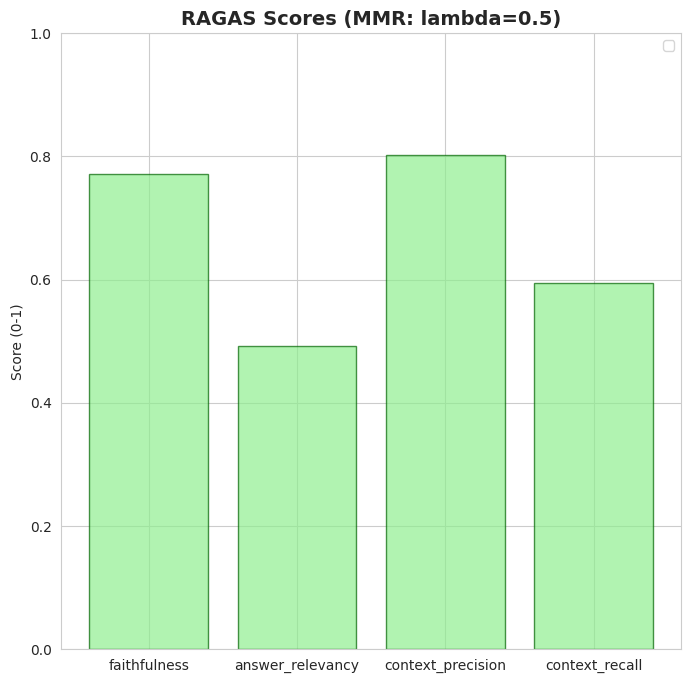

In [ ]:
results_df = ragas_results.to_pandas()
pdf_filename = "RAGAS_Evaluation_Report_MMR.pdf"

with PdfPages(pdf_filename) as pdf:
    sns.set_style("whitegrid")
    fig1 = plt.figure(figsize=(8, 8))

    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        scores = {col: results_df[col].mean() for col in metric_cols}
        plt.bar(scores.keys(), scores.values(), color='lightgreen', edgecolor='darkgreen', alpha=0.7)
        plt.title(f"RAGAS Scores (MMR: lambda={MMR_LAMBDA_MULT})", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1)
        plt.legend()

    if metric_cols:
        stats_df = results_df[metric_cols].describe().round(3)
        fig2 = plt.figure(figsize=(10, 6))
        plt.axis('off')
        plt.title("Detailed Statistics (MMR Retrieval)", fontsize=16, fontweight='bold', pad=20)

        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)

        pdf.savefig(fig2)
        plt.close(fig2)

print(f"PDF saved: {pdf_filename}")